# Benchmark Training Analysis

Use this notebook to monitor the progress of your submitted jobs.

In [1]:
import sys
import os
import re
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def parse_logs(log_file):
    train_losses = []
    val_losses = []
    
    if not os.path.exists(log_file):
        print(f"Log file not found: {log_file}")
        return [], []
    
    print(f"Parsing logs from: {log_file}")
    with open(log_file, 'r') as f:
        for line in f:
            if "loss" in line and "Epoch" in line and "Batch" in line:
                match = re.search(r"loss ([0-9.]+)", line)
                if match:
                    train_losses.append(float(match.group(1)))
            
            if "avg validation loss" in line:
                match = re.search(r"loss ([0-9.]+)", line)
                if match:
                    val_losses.append(float(match.group(1)))
                    
    return train_losses, val_losses

def plot_training_progress(exp_dir):
    log_file = os.path.join(exp_dir, 'train.log')
    train_losses, val_losses = parse_logs(log_file)
    
    if not train_losses:
        print("No training data found yet.")
        return
    
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, alpha=0.3, label='Training Loss (Batch)', color='blue')
    
    window = 50
    if len(train_losses) > window:
        smooth_train = np.convolve(train_losses, np.ones(window)/window, mode='valid')
        plt.plot(np.arange(len(smooth_train)) + window//2, smooth_train, label='Training Loss (Smoothed)', color='darkblue')
        
    if len(val_losses) > 0:
        # Estimate epoch steps roughly
        steps_per_epoch = len(train_losses) // max(1, len(val_losses))
        val_indices = np.arange(1, len(val_losses) + 1) * steps_per_epoch
        # Clip to max
        val_indices = np.minimum(val_indices, len(train_losses) - 1)
        plt.plot(val_indices, val_losses, 'r-o', label='Validation Loss (Logged)', linewidth=2, markersize=8)
        plt.annotate(f'{val_losses[-1]:.4f}', (val_indices[-1], val_losses[-1]), textcoords="offset points", xytext=(0,10), ha='center', color='red')
        
    plt.xlabel('Training Steps (Batches)')
    plt.ylabel('Loss')
    plt.title(f'Training Progress - {os.path.basename(exp_dir)}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

## Monitor Benchmark Run
Update the path below to your running job found in `../experiments_shortcut/fno/...`

Parsing logs from: ../experiments_shortcut/fno/2026-02-05/21-09-51/train.log


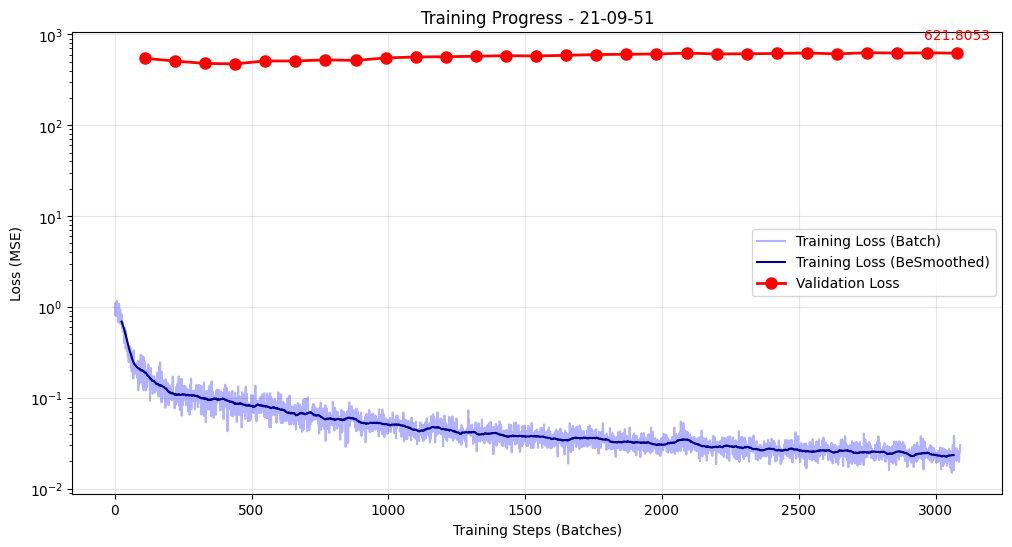

In [27]:
# Set your experiment directory here
EXP_DIR = "../experiments_shortcut/fno/2026-02-05/21-09-51"
plot_training_progress(EXP_DIR)

## Manual Validation Checking
Use this cell to load the checkpoint directly and verify the true validation loss, bypassing any logging bugs.

In [25]:
import torch
import hydra
import os
from the_well.data.datamodule import WellDataModule
from torch.nn import MSELoss

# 1. Define Checkpoint Path
# Check both possible locations (root checkpoints or '0' subdir checkpoints)
possible_paths = [
    os.path.join(EXP_DIR, "checkpoints", "last.pt"),
    os.path.join(EXP_DIR, "0", "checkpoints", "last.pt")
]

ckpt_path = None
for p in possible_paths:
    if os.path.exists(p):
        ckpt_path = p
        break

if ckpt_path is None:
    print(f" Waiting for checkpoint... (Checked: {possible_paths})")
else:
    print(f"Loading model from: {ckpt_path}")
    # 2. Load Checkpoint
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    cfg = checkpoint.get('config')
    
    if not cfg:
        print("Error: Config not found in checkpoint.")
    else:
        print("Config loaded successfully.")
        
        # 3. Setup Data
        print("Initializing DataModule...")
        datamodule = WellDataModule(cfg.data)
        datamodule.setup()
        val_loader = datamodule.val_dataloader()
        
        # 4. Setup Model
        print("Initializing Model...")
        # Use hydra instantiate to ensure correct model class/params
        model = hydra.utils.instantiate(cfg.model)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        # 5. Run Manual Validation
        print("Running validation batch...")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = model.to(device)
        
        loss_fn = MSELoss()
        total_loss = 0.0
        num_batches = 0
        
        with torch.no_grad():
            for i, batch in enumerate(val_loader):
                # Move data to device (fields usually in batch['input_fields'])
                # Note: DataFormatter logic might be needed if raw batch is dict
                # For simplicity, assuming standard structure or manual extraction if needed
                
                # Quick check of batch structure
                if i == 0: 
                    print(f"Batch keys: {batch.keys()}")
                
                # NOTE: We need the exact formatting logic from training.py
                # But effectively: input is x, target is y.
                # datamodule yields: {'input_fields': ..., 'output_fields': ..., 'constant_fields': ...}
                
                x = batch['input_fields'].to(device) 
                y = batch['output_fields'].to(device)
                
                # Run Model
                # FNO expects (batch, x, y, ...) or similar?
                # Based on training.py: inputs, _ = formatter.process_input(batch)
                # For FNO, input is usually just the field tensor
                
                y_pred = model(x)
                
                # Calculate Normalized Loss
                # Ensure shapes match
                if y_pred.shape != y.shape:
                     # Sometimes model output needs cropping or reshaping
                     print(f"Shape mismatch! Pred: {y_pred.shape}, Target: {y.shape}")
                     # Adjust if necessary (e.g. channel last vs first)
                     # But for FNO typically it matches
                     pass
                
                loss = loss_fn(y_pred, y)
                total_loss += loss.item()
                num_batches += 1
                
                if i >= 10: # Just check 10 batches for speed
                    break
        
        avg_loss = total_loss / num_batches
        print(f"\nCompleted Manual Validation over {num_batches} batches.")
        print(f"\033[92mTRUE NORMALIZED VALIDATION LOSS: {avg_loss:.6f}\033[0m")


 Waiting for checkpoint... (Checked: ['../experiments_shortcut/fno/2026-02-05/21-09-51/checkpoints/last.pt', '../experiments_shortcut/fno/2026-02-05/21-09-51/0/checkpoints/last.pt'])
